In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 3.0.6
numpy: 2.4.6


In [2]:
df = sns.load_dataset("titanic")

print("Размер таблицы:", df.shape)
print()
print(df.head())

Размер таблицы: (891, 15)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB


In [4]:
print("Типы колонок:")
print(df.dtypes)
print()
print("Колонки по типам:")
for dtype in df.dtypes.unique():
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"  {dtype}: {cols}")

Типы колонок:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Колонки по типам:
  int64: ['survived', 'pclass', 'sibsp', 'parch']
  str: ['sex', 'embarked', 'who', 'embark_town', 'alive']
  float64: ['age', 'fare']
  category: ['class', 'deck']
  bool: ['adult_male', 'alone']
  category: ['class', 'deck']


In [5]:
df["age"] = df.groupby(["sex", "pclass"])["age"].transform(
    lambda x: x.fillna(x.median())
)

In [6]:
# Копируем датафрейм, чтобы не портить оригинал
df_clean = df.copy()

# 1. Удаляем колонки: утечка + дубликаты
cols_to_drop = ["alive", "class", "embark_town", "who", "adult_male", "deck"]
df_clean = df_clean.drop(columns=cols_to_drop)

print("Колонок после удаления:", df_clean.shape[1])
print("Осталось:", df_clean.columns.tolist())

Колонок после удаления: 9
Осталось: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


In [7]:
df_clean = df_clean.dropna(subset=["embarked"])

print("Строк после удаления:", df_clean.shape[0])

Строк после удаления: 889


In [8]:
df_clean["age"] = df_clean.groupby(["sex", "pclass"])["age"].transform(
    lambda x: x.fillna(x.median())
)

print("Пропусков в age после заполнения:", df_clean["age"].isna().sum())

Пропусков в age после заполнения: 0


In [9]:
print("Пропусков по колонкам:")
print(df_clean.isna().sum())

Пропусков по колонкам:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [10]:
print("Размер:", df_clean.shape)
print()
print(df_clean.head())
print()
df_clean.info()

Размер: (889, 9)

   survived  pclass     sex   age  sibsp  parch     fare embarked  alone
0         0       3    male  22.0      1      0   7.2500        S  False
1         1       1  female  38.0      1      0  71.2833        C  False
2         1       3  female  26.0      0      0   7.9250        S   True
3         1       1  female  35.0      1      0  53.1000        S  False
4         0       3    male  35.0      0      0   8.0500        S   True

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    str    
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    str    
 8   alone     889 non-null    bool   
dtypes: bool(1), float64(2

In [11]:
df_clean.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,889.00,889.00,889.00,889.00,889.00,889.00
mean,0.38,2.31,29.07,0.52,0.38,32.10
std,0.49,0.83,13.27,1.10,0.81,49.70
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,21.50,0.00,0.00,7.90
50%,0.00,3.00,26.00,0.00,0.00,14.45
75%,1.00,3.00,36.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


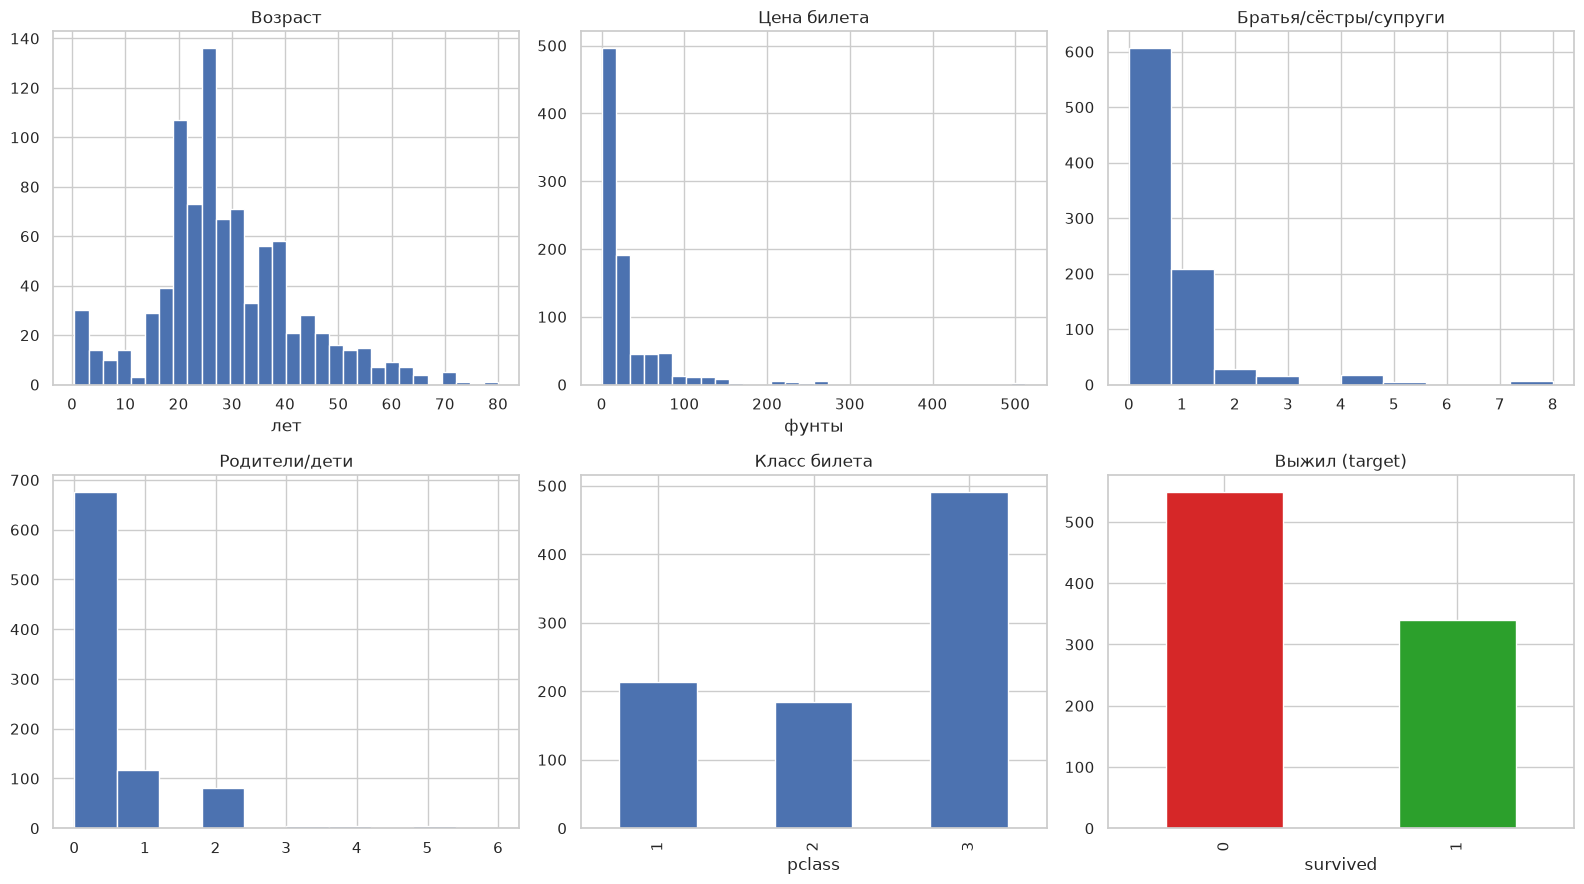

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

df_clean["age"].hist(bins=30, ax=axes[0, 0])
axes[0, 0].set_title("Возраст")
axes[0, 0].set_xlabel("лет")

df_clean["fare"].hist(bins=30, ax=axes[0, 1])
axes[0, 1].set_title("Цена билета")
axes[0, 1].set_xlabel("фунты")

df_clean["sibsp"].hist(bins=10, ax=axes[0, 2])
axes[0, 2].set_title("Братья/сёстры/супруги")

df_clean["parch"].hist(bins=10, ax=axes[1, 0])
axes[1, 0].set_title("Родители/дети")

df_clean["pclass"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 1])
axes[1, 1].set_title("Класс билета")

df_clean["survived"].value_counts().sort_index().plot(kind="bar", ax=axes[1, 2], color=["#d62728", "#2ca02c"])
axes[1, 2].set_title("Выжил (target)")

plt.tight_layout()
plt.show()

In [13]:
df_clean["has_sibling"] = (df_clean["sibsp"] > 0).astype(int)
df_clean["has_parent"] = (df_clean["parch"] > 0).astype(int)

print("Проверка:")
print(df_clean[["sibsp", "has_sibling", "parch", "has_parent"]].head(10))
print()
print("Распределение has_sibling:")
print(df_clean["has_sibling"].value_counts())
print()
print("Распределение has_parent:")
print(df_clean["has_parent"].value_counts())

Проверка:
   sibsp  has_sibling  parch  has_parent
0      1            1      0           0
1      1            1      0           0
2      0            0      0           0
3      1            1      0           0
4      0            0      0           0
5      0            0      0           0
6      0            0      0           0
7      3            1      1           1
8      0            0      2           1
9      1            1      0           0

Распределение has_sibling:
has_sibling
0    606
1    283
Name: count, dtype: int64

Распределение has_parent:
has_parent
0    676
1    213
Name: count, dtype: int64


In [14]:
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1

print("Размер семьи:")
print(df_clean["family_size"].value_counts().sort_index())
print()
print(df_clean["family_size"].describe().round(2))

Размер семьи:
family_size
1     535
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

count    889.00
mean       1.91
std        1.61
min        1.00
25%        1.00
50%        1.00
75%        2.00
max       11.00
Name: family_size, dtype: float64


In [15]:
df_clean["fare_log"] = np.log1p(df_clean["fare"])

print("Было (fare):")
print(df_clean["fare"].describe().round(2))
print()
print("Стало (fare_log):")
print(df_clean["fare_log"].describe().round(2))

Было (fare):
count    889.00
mean      32.10
std       49.70
min        0.00
25%        7.90
50%       14.45
75%       31.00
max      512.33
Name: fare, dtype: float64

Стало (fare_log):
count    889.00
mean       2.96
std        0.97
min        0.00
25%        2.19
50%        2.74
75%        3.47
max        6.24
Name: fare_log, dtype: float64


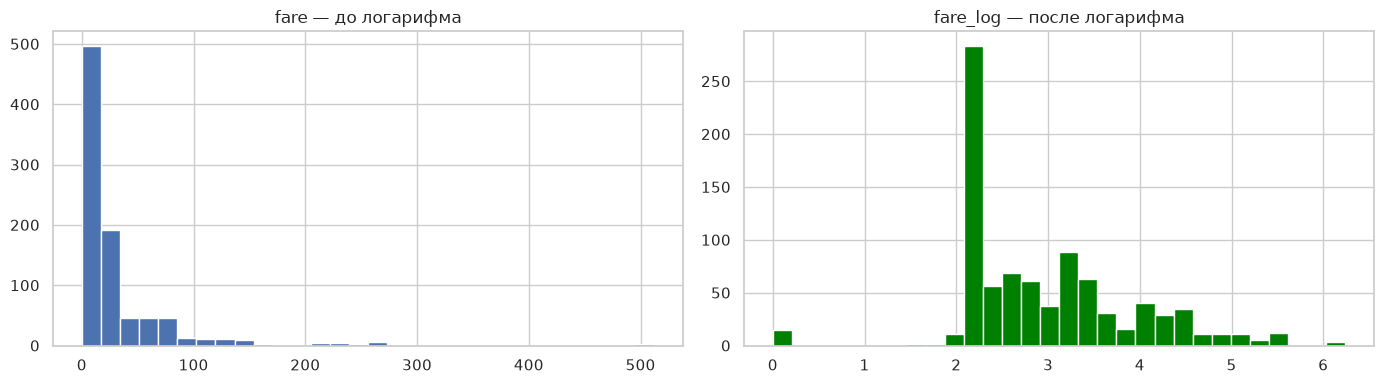

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_clean["fare"].hist(bins=30, ax=axes[0])
axes[0].set_title("fare — до логарифма")

df_clean["fare_log"].hist(bins=30, ax=axes[1], color="green")
axes[1].set_title("fare_log — после логарифма")

plt.tight_layout()
plt.show()

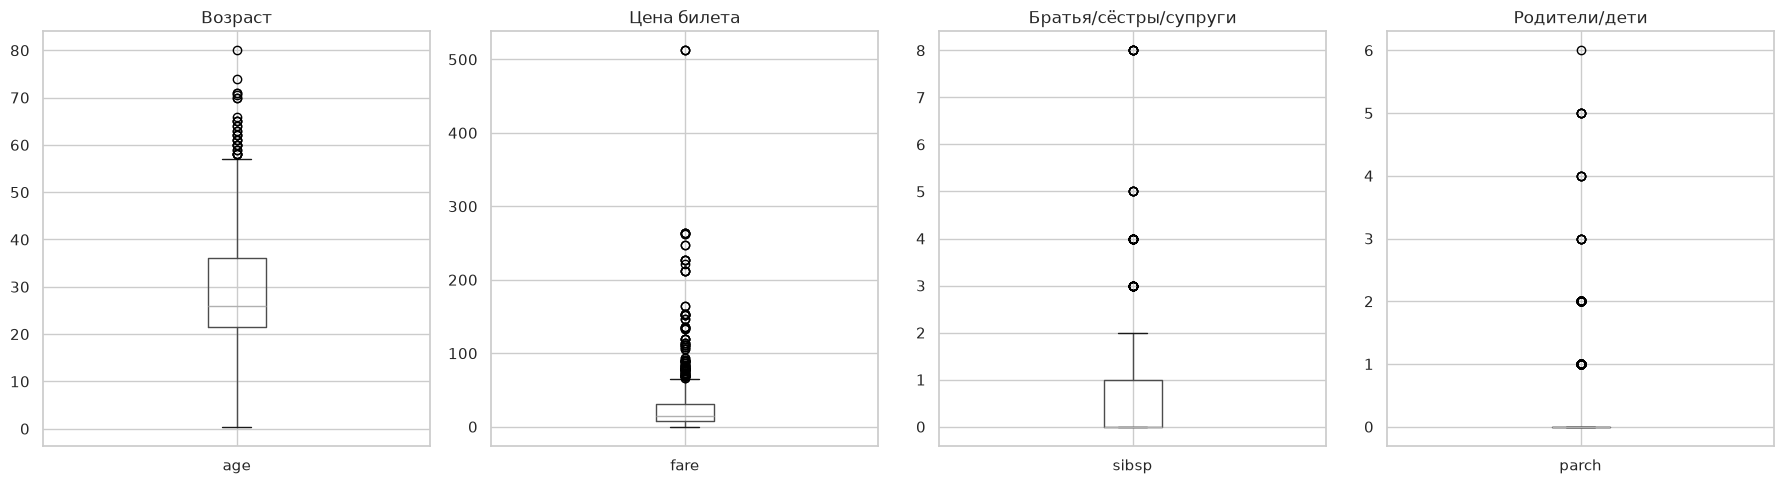

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

df_clean.boxplot(column="age", ax=axes[0])
axes[0].set_title("Возраст")

df_clean.boxplot(column="fare", ax=axes[1])
axes[1].set_title("Цена билета")

df_clean.boxplot(column="sibsp", ax=axes[2])
axes[2].set_title("Братья/сёстры/супруги")

df_clean.boxplot(column="parch", ax=axes[3])
axes[3].set_title("Родители/дети")

plt.tight_layout()
plt.show()

In [18]:
def count_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr
    return ((series < low) | (series > high)).sum()

print("Количество выбросов по правилу 1.5 × IQR:")
print()
for col in ["age", "fare", "sibsp", "parch"]:
    n = count_outliers(df_clean[col])
    pct = n / len(df_clean) * 100
    print(f"  {col:8s}: {n:4d} ({pct:.1f}%)")

Количество выбросов по правилу 1.5 × IQR:

  age     :   32 (3.6%)
  fare    :  114 (12.8%)
  sibsp   :   46 (5.2%)
  parch   :  213 (24.0%)


In [19]:
# Пассажиры с самыми дорогими билетами
top_fare = df_clean.nlargest(15, "fare")[
    ["fare", "pclass", "sex", "age", "survived", "fare_log"]
]
print("Топ-15 самых дорогих билетов:")
print(top_fare)

Топ-15 самых дорогих билетов:
         fare  pclass     sex   age  survived  fare_log
258  512.3292       1  female  35.0         1  6.240917
679  512.3292       1    male  36.0         1  6.240917
737  512.3292       1    male  35.0         1  6.240917
27   263.0000       1    male  19.0         0  5.575949
88   263.0000       1  female  23.0         1  5.575949
341  263.0000       1  female  24.0         1  5.575949
438  263.0000       1    male  64.0         0  5.575949
311  262.3750       1  female  18.0         1  5.573579
742  262.3750       1  female  21.0         1  5.573579
118  247.5208       1    male  24.0         0  5.515527
299  247.5208       1  female  50.0         1  5.515527
380  227.5250       1  female  42.0         1  5.431646
557  227.5250       1    male  40.0         0  5.431646
700  227.5250       1  female  18.0         1  5.431646
716  227.5250       1  female  38.0         1  5.431646


In [20]:
n_log = count_outliers(df_clean["fare_log"])
print(f"Выбросов в fare:      {count_outliers(df_clean['fare'])}")
print(f"Выбросов в fare_log:  {n_log}")

Выбросов в fare:      114
Выбросов в fare_log:  31


In [21]:
numeric_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare", "fare_log"]
corr = df_clean[numeric_cols].corr().round(2)
corr

,survived,pclass,age,sibsp,parch,fare,fare_log
survived,1.00,-0.34,-0.06,-0.03,0.08,0.26,0.33
pclass,-0.34,1.00,-0.41,0.08,0.02,-0.55,-0.66
age,-0.06,-0.41,1.00,-0.25,-0.17,0.12,0.14
sibsp,-0.03,0.08,-0.25,1.00,0.41,0.16,0.32
parch,0.08,0.02,-0.17,0.41,1.00,0.22,0.33
fare,0.26,-0.55,0.12,0.16,0.22,1.00,0.79
fare_log,0.33,-0.66,0.14,0.32,0.33,0.79,1.00


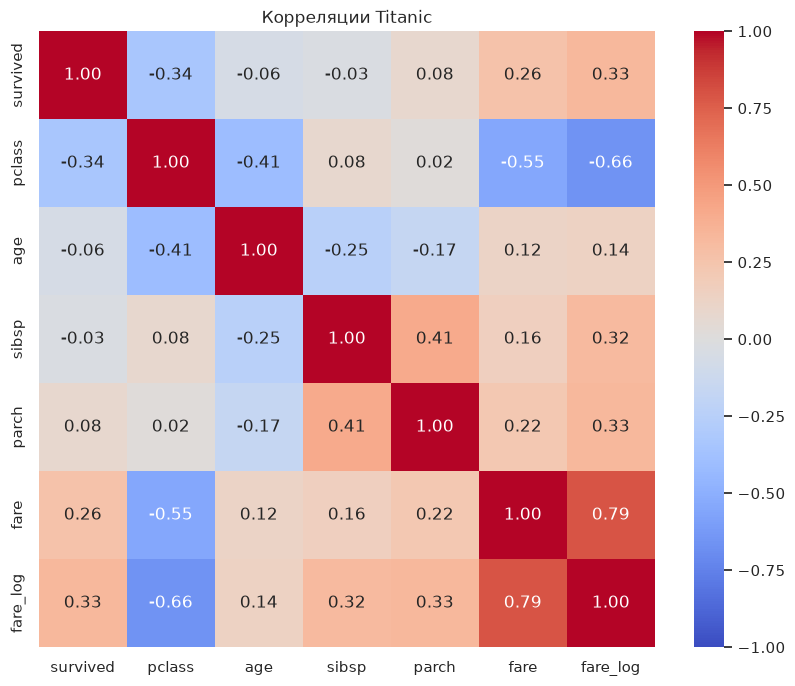

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, square=True, fmt=".2f")
plt.title("Корреляции Titanic")
plt.show()

In [23]:
corr_target = df_clean[numeric_cols].corr()["survived"].sort_values(ascending=False)
print("Корреляции с survived:")
print(corr_target.round(3))

Корреляции с survived:
survived    1.000
fare_log    0.327
fare        0.255
parch       0.083
sibsp      -0.034
age        -0.064
pclass     -0.336
Name: survived, dtype: float64


In [24]:
print("Выживаемость по полу:")
print(df_clean.groupby("sex")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по полу:
        count   mean
sex                 
female    312  0.740
male      577  0.189


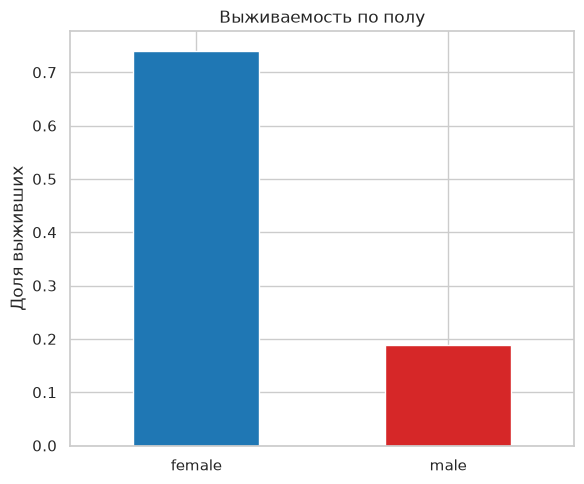

In [25]:
fig, ax = plt.subplots(figsize=(6, 5))
df_clean.groupby("sex")["survived"].mean().plot(kind="bar", ax=ax, color=["#1f77b4", "#d62728"])
ax.set_title("Выживаемость по полу")
ax.set_ylabel("Доля выживших")
ax.set_xlabel("")
ax.set_xticklabels(["female", "male"], rotation=0)
plt.tight_layout()
plt.show()

In [26]:
print("Выживаемость по классу:")
print(df_clean.groupby("pclass")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по классу:
        count   mean
pclass              
1         214  0.626
2         184  0.473
3         491  0.242


In [27]:
pivot = df_clean.groupby(["sex", "pclass"])["survived"].mean().round(3).unstack()
print("Выживаемость по полу и классу:")
print(pivot)

Выживаемость по полу и классу:
pclass      1      2      3
sex                        
female  0.967  0.921  0.500
male    0.369  0.157  0.135


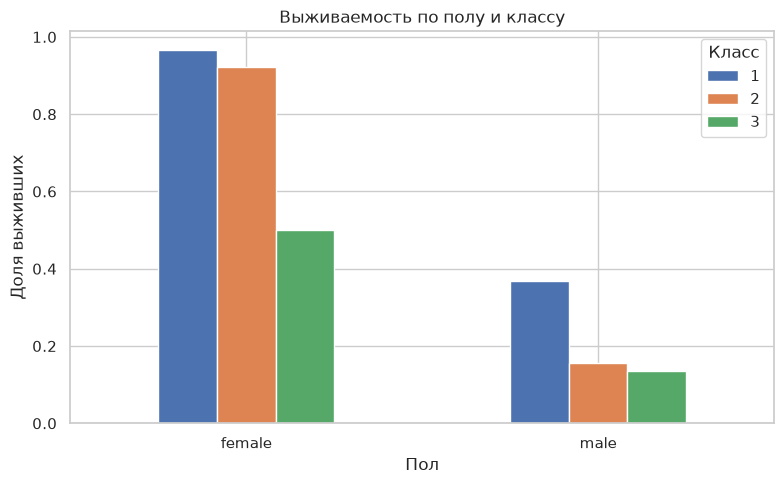

In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", ax=ax)
ax.set_title("Выживаемость по полу и классу")
ax.set_ylabel("Доля выживших")
ax.set_xlabel("Пол")
ax.set_xticklabels(["female", "male"], rotation=0)
ax.legend(title="Класс")
plt.tight_layout()
plt.show()

In [29]:
print("Выживаемость по порту посадки:")
print(df_clean.groupby("embarked")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по порту посадки:
          count   mean
embarked              
C           168  0.554
Q            77  0.390
S           644  0.337


In [30]:
df_clean["age_bin"] = pd.cut(df_clean["age"], bins=[0, 10, 20, 30, 40, 50, 60, 100],
                              labels=["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60+"])

print("Выживаемость по возрастным группам:")
print(df_clean.groupby("age_bin", observed=True)["survived"].agg(["count", "mean"]).round(3))

Выживаемость по возрастным группам:
         count   mean
age_bin              
0-10        64  0.594
10-20      115  0.383
20-30      377  0.324
30-40      184  0.446
40-50       86  0.384
50-60       42  0.405
60+         21  0.190


In [31]:
print("Выживаемость по parch:")
print(df_clean.groupby("parch")["survived"].agg(["count", "mean"]).round(3))

Выживаемость по parch:
       count   mean
parch              
0        676  0.342
1        118  0.551
2         80  0.500
3          5  0.600
4          4  0.000
5          5  0.200
6          1  0.000


In [32]:
print("Выживаемость по полу:")
print(df_clean.groupby("sex")["survived"].agg(["count", "mean"]).round(3))

print()
print("Выживаемость по классу:")
print(df_clean.groupby("pclass")["survived"].agg(["count", "mean"]).round(3))

print()
print("Выживаемость по полу и классу:")
pivot = df_clean.groupby(["sex", "pclass"])["survived"].mean().round(3).unstack()
print(pivot)

Выживаемость по полу:
        count   mean
sex                 
female    312  0.740
male      577  0.189

Выживаемость по классу:
        count   mean
pclass              
1         214  0.626
2         184  0.473
3         491  0.242

Выживаемость по полу и классу:
pclass      1      2      3
sex                        
female  0.967  0.921  0.500
male    0.369  0.157  0.135


In [33]:
print("Дубликатов строк:", df_clean.duplicated().sum())

Дубликатов строк: 118


In [34]:
print("Баланс классов:")
print(df_clean["survived"].value_counts())
print()
print("Доли:")
print(df_clean["survived"].value_counts(normalize=True).round(3))

Баланс классов:
survived
0    549
1    340
Name: count, dtype: int64

Доли:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


In [35]:
for col in ["sex", "embarked"]:
    print(f"\n=== {col} ===")
    print(df_clean[col].value_counts())


=== sex ===
sex
male      577
female    312
Name: count, dtype: int64

=== embarked ===
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [36]:
print("Размер:", df_clean.shape)
print("Пропуски:", df_clean.isna().sum().sum())
print()
print("Колонки:", df_clean.columns.tolist())

Размер: (889, 14)
Пропуски: 0

Колонки: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log', 'age_bin']


In [37]:
cols_to_drop = ["fare", "sibsp", "parch", "age_bin"]
df_model = df_clean.drop(columns=cols_to_drop).copy()

print("Колонок осталось:", df_model.shape[1])
print("Колонки:", df_model.columns.tolist())

Колонок осталось: 10
Колонки: ['survived', 'pclass', 'sex', 'age', 'embarked', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log']


In [38]:
df_model["sex"] = df_model["sex"].map({"male": 0, "female": 1})

print("sex после кодирования:")
print(df_model["sex"].value_counts())

sex после кодирования:
sex
0    577
1    312
Name: count, dtype: int64


In [39]:
df_model["alone"] = df_model["alone"].astype(int)

print("alone после кодирования:")
print(df_model["alone"].value_counts())

alone после кодирования:
alone
1    535
0    354
Name: count, dtype: int64


In [40]:
df_model = pd.get_dummies(df_model, columns=["embarked"], prefix="emb", drop_first=True)

print("Колонки после one-hot:")
print(df_model.columns.tolist())
print()
print(df_model.head())

Колонки после one-hot:
['survived', 'pclass', 'sex', 'age', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log', 'emb_Q', 'emb_S']

   survived  pclass  sex   age  alone  has_sibling  has_parent  family_size  \
0         0       3    0  22.0      0            1           0            2   
1         1       1    1  38.0      0            1           0            2   
2         1       3    1  26.0      1            0           0            1   
3         1       1    1  35.0      0            1           0            2   
4         0       3    0  35.0      1            0           0            1   

   fare_log  emb_Q  emb_S  
0  2.110213  False   True  
1  4.280593  False  False  
2  2.188856  False   True  
3  3.990834  False   True  
4  2.202765  False   True  


In [41]:
print("Типы колонок:")
print(df_model.dtypes)
print()
print("Размер:", df_model.shape)

Типы колонок:
survived         int64
pclass           int64
sex              int64
age            float64
alone            int64
has_sibling      int64
has_parent       int64
family_size      int64
fare_log       float64
emb_Q             bool
emb_S             bool
dtype: object

Размер: (889, 11)


In [42]:
y = df_model["survived"]
X = df_model.drop(columns=["survived"])

print("X (признаки):", X.shape)
print("y (target):  ", y.shape)
print()
print("Признаки:", X.columns.tolist())

X (признаки): (889, 10)
y (target):   (889,)

Признаки: ['pclass', 'sex', 'age', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log', 'emb_Q', 'emb_S']


In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test: ", X_test.shape)
print()
print("Доля выживших в train:", y_train.mean().round(3))
print("Доля выживших в test: ", y_test.mean().round(3))

Train: (711, 10)
Test:  (178, 10)

Доля выживших в train: 0.383
Доля выживших в test:  0.382


In [1]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# DummyClassifier(strategy="most_frequent") — всегда предсказывает самый частый класс
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_acc = baseline.score(X_test, y_test)

print(f"Baseline (всегда 'погиб'): accuracy = {baseline_acc:.3f}")
print(f"Доля погибших в test:       {1 - y_test.mean():.3f}")

NameError: name 'X_train' is not defined

In [2]:
# ===== ИМПОРТЫ =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

# ===== ЗАГРУЗКА ДАННЫХ =====
df = sns.load_dataset("titanic")

# ===== КОПИЯ =====
df_clean = df.copy()

# ===== 1. УДАЛЯЕМ КОЛОНКИ: утечка + дубликаты + много пропусков =====
cols_to_drop = ["alive", "class", "embark_town", "who", "adult_male", "deck"]
df_clean = df_clean.drop(columns=cols_to_drop)

# ===== 2. УДАЛЯЕМ 2 СТРОКИ С ПРОПУСКОМ В EMBARKED =====
df_clean = df_clean.dropna(subset=["embarked"])

# ===== 3. ЗАПОЛНЯЕМ AGE МЕДИАНОЙ ПО ГРУППЕ (sex, pclass) =====
df_clean["age"] = df_clean.groupby(["sex", "pclass"])["age"].transform(
    lambda x: x.fillna(x.median())
)

# ===== 4. СОЗДАЁМ НОВЫЕ ПРИЗНАКИ =====
df_clean["has_sibling"] = (df_clean["sibsp"] > 0).astype(int)
df_clean["has_parent"]  = (df_clean["parch"] > 0).astype(int)
df_clean["family_size"] = df_clean["sibsp"] + df_clean["parch"] + 1
df_clean["fare_log"]    = np.log1p(df_clean["fare"])

# ===== 5. УБИРАЕМ ДУБЛИКАТЫ ПРИЗНАКОВ =====
df_model = df_clean.drop(columns=["fare", "sibsp", "parch"]).copy()

# ===== 6. КОДИРУЕМ КАТЕГОРИАЛЬНЫЕ =====
df_model["sex"]   = df_model["sex"].map({"male": 0, "female": 1})
df_model["alone"] = df_model["alone"].astype(int)
df_model = pd.get_dummies(df_model, columns=["embarked"], prefix="emb", drop_first=True)

# ===== 7. СОБИРАЕМ X и y =====
y = df_model["survived"]
X = df_model.drop(columns=["survived"])

# ===== 8. TRAIN/TEST SPLIT =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===== ПРОВЕРКА =====
print("X:", X.shape)
print("y:", y.shape)
print()
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print()
print("Признаки:", X.columns.tolist())
print()
print("Доля выживших в train:", y_train.mean().round(3))
print("Доля выживших в test: ", y_test.mean().round(3))

X: (889, 10)
y: (889,)

X_train: (711, 10)
X_test:  (178, 10)

Признаки: ['pclass', 'sex', 'age', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log', 'emb_Q', 'emb_S']

Доля выживших в train: 0.383
Доля выживших в test:  0.382


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# DummyClassifier(strategy="most_frequent") — всегда предсказывает самый частый класс
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

baseline_acc = baseline.score(X_test, y_test)

print(f"Baseline (всегда 'погиб'): accuracy = {baseline_acc:.3f}")
print(f"Доля погибших в test:       {1 - y_test.mean():.3f}")

Baseline (всегда 'погиб'): accuracy = 0.618
Доля погибших в test:       0.618


In [4]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

train_acc = logreg.score(X_train, y_train)
test_acc = logreg.score(X_test, y_test)

print(f"LogReg — train: {train_acc:.3f}")
print(f"LogReg — test:  {test_acc:.3f}")
print(f"Разница:        {train_acc - test_acc:+.3f}")

LogReg — train: 0.806
LogReg — test:  0.826
Разница:        -0.020


In [5]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

train_acc_rf = rf.score(X_train, y_train)
test_acc_rf = rf.score(X_test, y_test)

print(f"RandomForest — train: {train_acc_rf:.3f}")
print(f"RandomForest — test:  {test_acc_rf:.3f}")
print(f"Разница:              {train_acc_rf - test_acc_rf:+.3f}")

RandomForest — train: 0.861
RandomForest — test:  0.815
Разница:              +0.046


In [6]:
models = {
    "Baseline": baseline,
    "LogReg": logreg,
    "RandomForest": rf,
}

results = []
for name, model in models.items():
    acc = model.score(X_test, y_test)
    results.append({"model": name, "test_acc": acc})

results_df = pd.DataFrame(results).sort_values("test_acc", ascending=False)
print(results_df.round(3))

          model  test_acc
1        LogReg     0.826
2  RandomForest     0.815
0      Baseline     0.618


In [7]:
from sklearn.metrics import confusion_matrix, classification_report

best_model = rf  # замени на победителя
preds = best_model.predict(X_test)

cm = confusion_matrix(y_test, preds)
cm_df = pd.DataFrame(
    cm,
    index=["правда: погиб", "правда: выжил"],
    columns=["предсказано: погиб", "предсказано: выжил"],
)
print(cm_df)
print()
print(classification_report(y_test, preds, target_names=["погиб", "выжил"]))

               предсказано: погиб  предсказано: выжил
правда: погиб                 101                   9
правда: выжил                  24                  44

              precision    recall  f1-score   support

       погиб       0.81      0.92      0.86       110
       выжил       0.83      0.65      0.73        68

    accuracy                           0.81       178
   macro avg       0.82      0.78      0.79       178
weighted avg       0.82      0.81      0.81       178



In [8]:
importances = pd.DataFrame({
    "признак": X.columns,
    "важность": rf.feature_importances_,
}).sort_values("важность", ascending=False)

print(importances.round(3))

       признак  важность
1          sex     0.420
7     fare_log     0.173
0       pclass     0.128
2          age     0.128
6  family_size     0.070
9        emb_S     0.027
3        alone     0.018
8        emb_Q     0.016
4  has_sibling     0.011
5   has_parent     0.010


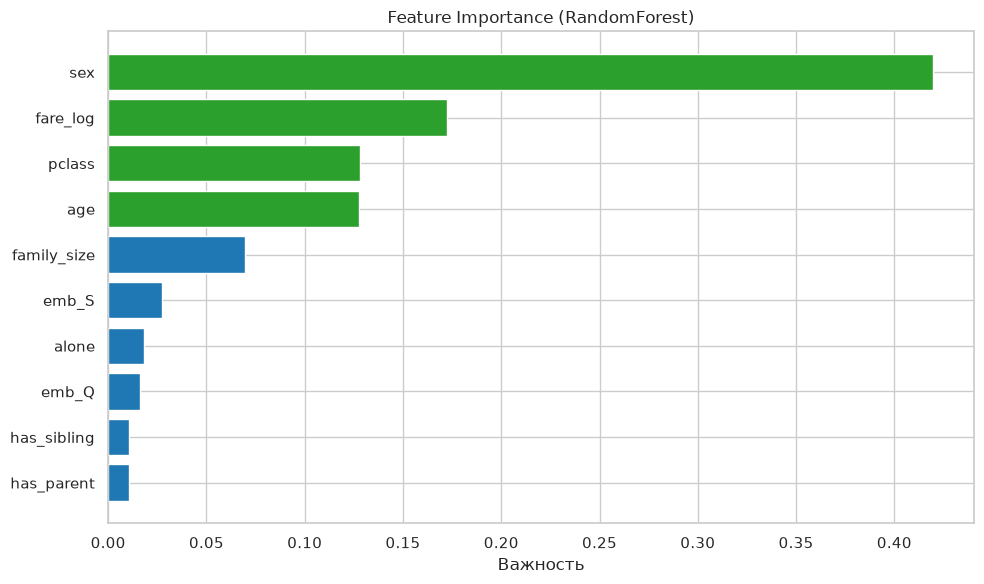

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ca02c" if v > 0.1 else "#1f77b4" for v in importances["важность"]]
ax.barh(importances["признак"], importances["важность"], color=colors)
ax.set_xlabel("Важность")
ax.set_title("Feature Importance (RandomForest)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [10]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X, y, cv=5, scoring="accuracy")

print("CV accuracy (5 фолдов):", cv_scores.round(3))
print(f"Среднее: {cv_scores.mean():.3f}")
print(f"Std:     {cv_scores.std():.3f}")

CV accuracy (5 фолдов): [0.77  0.815 0.86  0.787 0.831]
Среднее: 0.812
Std:     0.032


In [11]:
for depth in [3, 5, 7, 10, None]:
    rf_d = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    scores = cross_val_score(rf_d, X, y, cv=5, scoring="accuracy")
    print(f"max_depth={str(depth):>4}: mean={scores.mean():.3f}, std={scores.std():.3f}")

max_depth=   3: mean=0.811, std=0.040
max_depth=   5: mean=0.812, std=0.032
max_depth=   7: mean=0.821, std=0.022
max_depth=  10: mean=0.825, std=0.036
max_depth=None: mean=0.813, std=0.031


In [12]:
import joblib

# Сохраняем лучшую модель (LogReg)
joblib.dump(logreg, "titanic_logreg.joblib")
print("Модель сохранена: titanic_logreg.joblib")

# Сохраняем список признаков — критично для прода!
feature_names = X.columns.tolist()
joblib.dump(feature_names, "titanic_features.joblib")
print("Признаки сохранены:", feature_names)

Модель сохранена: titanic_logreg.joblib
Признаки сохранены: ['pclass', 'sex', 'age', 'alone', 'has_sibling', 'has_parent', 'family_size', 'fare_log', 'emb_Q', 'emb_S']
